In [1]:
galaxy_id = "g8.26e11"
component_str = "None"
split_file = "./data/gsf/g8.13e11.01024.halo_1.align_with_star.star.gmm_on_jzjcjpjcexyz.scikit_gmm_full_4clusters_white.decontaminated.dat"

# For emiles safe geckos template

age: [ 0.03      ,  0.04      ,  0.05      ,  0.06      ,  0.07      ,
        0.08      ,  0.09      ,  0.09999999,  0.14999999,  0.19999999,
        0.25      ,  0.29999998,  0.35      ,  0.39999998,  0.45      ,
        0.5       ,  0.59999996,  0.7       ,  0.79999995,  0.9       ,
        1.        ,  1.25      ,  1.5       ,  1.75      ,  2.        ,
        2.2499998 ,  2.5       ,  2.75      ,  3.        ,  3.2499998 ,
        3.5       ,  3.75      ,  4.        ,  4.4999995 ,  5.        ,
        5.5       ,  6.        ,  6.4999995 ,  7.        ,  7.5       ,
        8.        ,  8.499999  ,  8.999999  ,  9.5       , 10.        ,
       10.499999  , 11.        , 11.5       , 12.        , 12.499999  ,
       12.999999  , 13.5       , 14.        ], dtype=float32), 
       
metallicity=Array([0.0001, 0.0003, 0.0006, 0.001 , 0.002 , 0.004 , 0.008 , 0.01  ,
       0.0198, 0.024 , 0.03  , 0.04  ]

In [2]:
if component_str is None or component_str.strip() == "" or component_str == "None":
    component = None
else:
    component = component_str
    # split by comma and strip whitespace
#    component = [c.strip() for c in component_str.split(",")]

In [3]:
from jax import config
#config.update("jax_enable_x64", True)
#config.update('jax_num_cpu_devices', 8)

In [4]:
#NBVAL_SKIP
import os

# Tell XLA to fake 2 host CPU devices
#os.environ['XLA_FLAGS'] = '--xla_force_host_platform_device_count=3'

# Only make GPU 0 and GPU 1 visible to JAX:
os.environ['CUDA_VISIBLE_DEVICES'] = '0,1'

#os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"]   = "false"

import jax

# Now JAX will list two CpuDevice entries
print(jax.devices())
# → [CpuDevice(id=0), CpuDevice(id=1)]

[CpuDevice(id=0)]


In [5]:
# NBVAL_SKIP
#import os
#  os.environ['SPS_HOME'] = '/mnt/storage/annalena_data/sps_fsps'
#os.environ['SPS_HOME'] = '/home/annalena/sps_fsps'
#os.environ['SPS_HOME'] = '/Users/annalena/Documents/GitHub/fsps'
#os.environ['SPS_HOME'] = '/export/home/aschaibl/fsps'
os.environ['SPS_HOME'] = '/home/annalena_data/sps_fsps'

## Step 1: Config

In [6]:
#NBVAL_SKIP
import matplotlib.pyplot as plt
from rubix.core.pipeline import RubixPipeline 
import os

#galaxy_id = "g5.02e11"
#component = "ThinDisk" #None #"ThinDisk" #"ThickDisk" #"Halo" #"PseudoBulge"
#split_file = "./data/gsf/g5.02e11.01024.gmm_full_white_jzjcejpjc_5clusters_2018tags.dat"

config_NIHAO = {
    "pipeline":{"name": "calc_ifu_no_noise_no_psf"},
    
    "logger": {
        "log_level": "DEBUG",
        "log_file_path": None,
        "format": "%(asctime)s - %(name)s - %(levelname)s - %(message)s",
    },
    "data": {
        "name": "NihaoHandler",
        "args": {
            "particle_type": ["stars"],
            "save_data_path": "data",
            "snapshot": "1024",
        },
        "load_galaxy_args": {"reuse": True, "id": galaxy_id},
        "subset": {"use_subset": False, "subset_size": 5000},
    },
    "simulation": {
        "name": "NIHAO",
        "args": {
            #"path": f'/export/home/aschaibl/502e11/{galaxy_id}.01024',
            #"halo_path": f'/export/home/aschaibl/502e11/{galaxy_id}.01024.z0.000.AHF_halos',
            "path": f'/home/_data/nihao/nihao_classic/{galaxy_id}/{galaxy_id}.01024',
            "halo_path": f'/home/_data/nihao/nihao_classic/{galaxy_id}/{galaxy_id}.01024.z0.000.AHF_halos',
            "halo_id": 0,
        },
    },
    "output_path": "output",

    "telescope":
        {"name": "MUSE_HUB26",
         "psf": {"name": "gaussian", "size": 5, "sigma": 0.6},
         "lsf": {"sigma": 0.5},
         "noise": {"signal_to_noise": 0.1,"noise_distribution": "normal"},},
    "cosmology":
        {"name": "PLANCK15"},
        
    "galaxy":
        {"dist_z": 0.003,
         "rotation": {"type": "matrix"}, #{"alpha": 0.0, "beta": 0.0, "gamma":0.0},
         "component": component,#None, #["ThinDisk", "ThickDisk", "Halo", "PseudoBulge"], #None,
         "component_file": split_file, 
        },
        
    "ssp": {
        "template": {
            "name": "EMILES_BASTI_BASE_CH_FITS_safe" #"Mastar_CB19_SLOG_1_5" #"FSPS" #"BruzualCharlot2003" #"Mastar_CB19_SLOG_1_5"
        },
        "dust": {
                "extinction_model": "Cardelli89",
                "dust_to_gas_ratio": 0.005,
                "dust_to_metals_ratio": 0.4,
                "dust_grain_density": 3.5,
                "Rv": 3.1,
            },
    },        
}

2026-03-18 19:31:08,379 - rubix - INFO - 
   ___  __  _____  _____  __
  / _ \/ / / / _ )/  _/ |/_/
 / , _/ /_/ / _  |/ /_>  <
/_/|_|\____/____/___/_/|_|


2026-03-18 19:31:08,380 - rubix - INFO - Rubix version: 0.0.5.post12+g5069d55cf.d20260318
2026-03-18 19:31:08,380 - rubix - INFO - JAX version: 0.7.2
2026-03-18 19:31:08,381 - rubix - INFO - Running on [CpuDevice(id=0)] devices
2026-03-18 19:31:08,381 - rubix - WARNING - python-fsps is not installed. Install it via `pip install fsps` and see https://dfm.io/python-fsps/current/installation/ for details, including required environment variables.


In [7]:
print(config_NIHAO["galaxy"]["component"])

None


## Step 2: Pipeline yaml

## Step 3: Run the pipeline

After defining the `config` and the `pipeline_config` you can simply run the whole pipeline by these two lines of code.

In [8]:
#NBVAL_SKIP
pipe = RubixPipeline(config_NIHAO)

2026-03-18 19:31:08,704 - rubix - INFO - No telescope config provided, falling back to /home/annalena/.conda/envs/rubix/lib/python3.12/site-packages/rubix/telescope/telescopes.yaml
/home/annalena/.conda/envs/rubix/lib/python3.12/site-packages/rubix/telescope/factory.py:32: UserWarning: No telescope config provided, using default stored in /home/annalena/.conda/envs/rubix/lib/python3.12/site-packages/rubix/telescope/telescopes.yaml
  warnings.warn(


In [9]:
#NBVAL_SKIP

inputdata = pipe.prepare_data()

2026-03-18 19:31:08,929 - rubix - INFO - Getting rubix data...
2026-03-18 19:31:08,930 - rubix - INFO - Loading data into input handler
2026-03-18 19:31:08,930 - rubix - INFO - Using PynbodyHandler to load a NIHAO galaxy
2026-03-18 19:31:08,934 - rubix - INFO - Galaxy redshift (dist_z) set to: 0.003
2026-03-18 19:31:08,948 - rubix - INFO - Simulation snapshot loaded from halo 0
2026-03-18 19:31:09,048 - rubix - INFO - Halo data loaded.
2026-03-18 19:31:11,386 - rubix - INFO - Rotation matrix calculated and saved to '/notebooks/data/rotation_matrix.npy'.
2026-03-18 19:31:11,387 - rubix - INFO - Loaded halo data for halo ID 0 with 739749 particles.
2026-03-18 19:31:11,388 - rubix - INFO - Loading components from file: ./data/gsf/g8.13e11.01024.halo_1.align_with_star.star.gmm_on_jzjcjpjcexyz.scikit_gmm_full_4clusters_white.decontaminated.dat.
2026-03-18 19:31:11,388 - rubix - INFO - Filtering components by: None.
2026-03-18 19:31:11,408 - rubix - INFO - No component filtering; loading all

Converted to Rubix format!


2026-03-18 19:31:12,341 - rubix - INFO - Data loaded with 739749 star particles and 0 gas particles.
2026-03-18 19:31:12,342 - rubix - INFO - Data preparation completed in 3.41 seconds.


min x: -177
max x: 174
min y: -187
max y: 207
min z: -187
max z: 197

In [10]:
#inputdata.stars.coords[:,0].max()

In [11]:
#inputdata.stars.mass.max()

In [12]:
import jax
import jax.numpy as jnp

key = jax.random.PRNGKey(42)

#random_array = jax.random.uniform(key, shape=(40,), minval=10.0, maxval=14.0)
#inputdata.stars.age = jax.random.uniform(key, shape=(50,), minval=10.0, maxval=14.0)
#inputdata.stars.metallicity = jax.random.uniform(key, shape=(50,), minval=0.0001, maxval=0.04)
#inputdata.stars.mass = jax.random.uniform(key, shape=(50,), minval=1e5, maxval=10**6.5)
#inputdata.stars.velocity = jax.random.uniform(key, shape=(50, 3), minval=-100.0, maxval=100.0)
#inputdata.stars.coords = jax.random.uniform(key, shape=(50, 3), minval=-5.0, maxval=5.0)

gc_age = jax.random.uniform(key, shape=(50,), minval=10.0, maxval=14.0)
gc_metallicity = jax.random.uniform(key, shape=(50,), minval=0.0001, maxval=0.04)
gc_mass = jax.random.uniform(key, shape=(50,), minval=1e5, maxval=10**6.5)
gc_velocity = jax.random.uniform(key, shape=(50, 3), minval=0.0, maxval=100.0)
gc_coords = jax.random.uniform(key, shape=(50, 3), minval=0.0, maxval=150.0)

In [13]:
inputdata.stars.age = jnp.append(inputdata.stars.age, gc_age)
inputdata.stars.metallicity = jnp.append(inputdata.stars.metallicity, gc_metallicity)
inputdata.stars.mass = jnp.append(inputdata.stars.mass, gc_mass)
inputdata.stars.velocity = jnp.vstack((inputdata.stars.velocity, gc_velocity))
inputdata.stars.coords = jnp.vstack((inputdata.stars.coords, gc_coords))

In [14]:
import numpy as np
import jax.numpy as jnp

# 1. Combine your arrays into a single 2D array (50 rows, 9 columns)
# jnp.column_stack safely aligns 1D arrays and 2D arrays side-by-side.
combined_table = jnp.column_stack((
    gc_age,         # 1 column
    gc_metallicity, # 1 column
    gc_mass,        # 1 column
    gc_velocity,    # 3 columns (vx, vy, vz)
    gc_coords       # 3 columns (cx, cy, cz)
))

# 2. Define a header so you know which column is which in the text file
header_labels = "age metallicity mass vx vy vz cx cy cz"

# 3. Save to a text file using standard NumPy
# fmt="%.6e" saves the numbers in scientific notation (good for varying scales like mass vs metallicity)
np.savetxt("./output/hub2026/nihao826e11_gcs_no_noise_no_psf/gc_injected_data.txt", combined_table, header=header_labels, fmt="%.6e", comments="# ")

print("Data successfully saved to gc_injected_data.txt!")


Data successfully saved to gc_injected_data.txt!


In [15]:
#NBVAL_SKIP

rubixdata = pipe.run_sharded(inputdata)

2026-03-18 19:31:12,928 - rubix - INFO - Setting up the pipeline...
2026-03-18 19:31:12,928 - rubix - DEBUG - Pipeline Configuration: {'Transformers': {'rotate_galaxy': {'name': 'rotate_galaxy', 'depends_on': None, 'args': [], 'kwargs': {}}, 'filter_particles': {'name': 'filter_particles', 'depends_on': 'rotate_galaxy', 'args': [], 'kwargs': {}}, 'spaxel_assignment': {'name': 'spaxel_assignment', 'depends_on': 'filter_particles', 'args': [], 'kwargs': {}}, 'calculate_datacube_particlewise': {'name': 'calculate_datacube_particlewise', 'depends_on': 'spaxel_assignment', 'args': [], 'kwargs': {}}, 'convolve_lsf': {'name': 'convolve_lsf', 'depends_on': 'calculate_datacube_particlewise', 'args': [], 'kwargs': {}}}}
2026-03-18 19:31:12,930 - rubix - DEBUG - Roataion Type found: matrix
2026-03-18 19:31:12,932 - rubix - INFO - Calculating spatial bin edges...
2026-03-18 19:31:12,933 - rubix - INFO - No telescope config provided, falling back to /home/annalena/.conda/envs/rubix/lib/python3.12/s

In [16]:
#print(rubixdata)

## Convert luminosity to flux

In [17]:
from rubix.spectra.ifu import convert_luminoisty_to_flux
from rubix.cosmology import PLANCK15

observation_lum_dist = PLANCK15.luminosity_distance_to_z(config_NIHAO["galaxy"]["dist_z"])
observation_z = config_NIHAO["galaxy"]["dist_z"]
pixel_size = 1.0
fluxcube = convert_luminoisty_to_flux(rubixdata, observation_lum_dist, observation_z, pixel_size)
rubixdata = fluxcube/1e-20

## Store datacube in a fits file with header

In [18]:
#NBVAL_SKIP
from rubix.core.fits import store_fits

#if config_illustris["telescope"]["name"] == "MUSE_ultraWFM":
#    cutted_datatcube = data.stars.datacube[300:600, :, :]
#    data.stars.datacube = cutted_datatcube
#if config_illustris["telescope"]["name"] == "MUSE_WFM":
#    cutted_datatcube = data.stars.datacube[100:200, :, :]
#    data.stars.datacube = cutted_datatcube

store_fits(config_NIHAO, rubixdata, "./output/hub2026/nihao826e11_gcs_no_noise_no_psf/")

2026-03-18 19:31:19,307 - rubix - INFO - No telescope config provided, falling back to /home/annalena/.conda/envs/rubix/lib/python3.12/site-packages/rubix/telescope/telescopes.yaml
/home/annalena/.conda/envs/rubix/lib/python3.12/site-packages/rubix/telescope/factory.py:32: UserWarning: No telescope config provided, using default stored in /home/annalena/.conda/envs/rubix/lib/python3.12/site-packages/rubix/telescope/telescopes.yaml
  warnings.warn(
2026-03-18 19:56:23,267 - rubix - INFO - Datacube saved to ./output/hub2026/nihao826e11_gcs_no_noise_no_psf/NIHAO_idg8.26e11_snap1024_subsetFalse.fits


## Step 4: Mock-data

Now we have our final datacube and can use the mock-data to do science. Here we have a quick look in the optical wavelengthrange of the mock-datacube and show the spectra of a central spaxel and a spatial image.

In [19]:
#NBVAL_SKIP
import jax.numpy as jnp

wave = pipe.telescope.wave_seq
# get the indices of the visible wavelengths of 4000-8000 Angstroms
visible_indices = jnp.where((wave >= 4000) & (wave <= 8000))


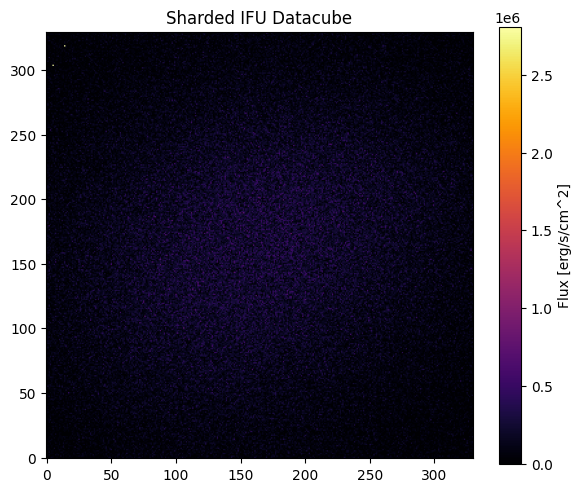

In [20]:
#NBVAL_SKIP
import numpy as np
# get the spectra of the visible wavelengths from the ifu cube
#visible_spectra = rubixdata.stars.datacube[ :, :, visible_indices[0]]
#visible_spectra = rubixdata[ :, :, visible_indices[0]]
sharded_visible_spectra = rubixdata[ :, :, visible_indices[0]]
#visible_spectra.shape

#image = jnp.sum(visible_spectra, axis=2)
sharded_image = jnp.sum(sharded_visible_spectra, axis=2)
img32 = np.array(sharded_image, dtype=np.float32)

# Plot side by side
plt.figure(figsize=(6, 5))

# Original IFU datacube image
#im0 = axes[0].imshow(image, origin="lower", cmap="inferno")
#axes[0].set_title("Original IFU Datacube")
#fig.colorbar(im0, ax=axes[0])

# Sharded IFU datacube image
plt.imshow(img32, origin="lower", cmap="inferno")
plt.title("Sharded IFU Datacube")
plt.colorbar(label="Flux [erg/s/cm^2]")

plt.tight_layout()
plt.savefig(f"./output/hub2026/nihao826e11_gcs_no_noise_no_psf/image_{galaxy_id}_{component}.jpeg")
plt.show()

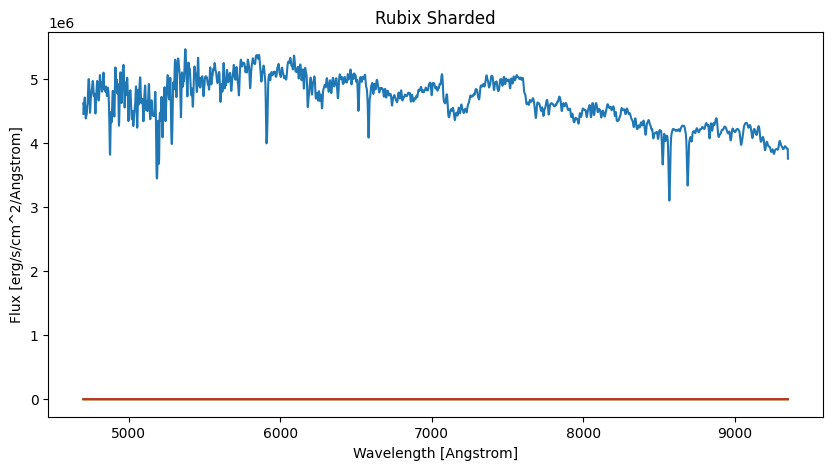

In [21]:
#NBVAL_SKIP
wave = pipe.telescope.wave_seq

#spectra = rubixdata#.stars.datacube # Spectra of all stars
spectra_sharded = rubixdata # Spectra of all stars
#print(spectra.shape)

plt.figure(figsize=(10, 5))
#plt.subplot(1, 2, 1)
#plt.title("Rubix")
#plt.xlabel("Wavelength [Angstrom]")
#plt.ylabel("Flux [erg/s/cm^2/Angstrom]")
#plt.plot(wave, spectra[12,12,:])
#plt.plot(wave, spectra[8,12,:])

summed_spectra = jnp.sum(spectra_sharded, axis=(0,1))
plt.plot(wave, summed_spectra)
#plt.subplot(1, 2, 2)
plt.title("Rubix Sharded")
plt.xlabel("Wavelength [Angstrom]")
plt.ylabel("Flux [erg/s/cm^2/Angstrom]")
plt.plot(wave, spectra_sharded[150,150,:])
plt.plot(wave, spectra_sharded[150,200,:])
plt.plot(wave, spectra_sharded[200,150,:])

plt.savefig(f"./output/hub2026/nihao826e11_gcs_no_noise_no_psf/spectra_{galaxy_id}_{component}.jpeg")
plt.show()

## DONE!

Congratulations, you have sucessfully run the RUBIX pipeline to create your own mock-observed IFU datacube! Now enjoy playing around with the RUBIX pipeline and enjoy doing amazing science with RUBIX :)

In [22]:
"""
# NBVAL_SKIP
from rubix.core.rotation import get_galaxy_rotation
rotate = get_galaxy_rotation(config_NIHAO)

inputdata = rotate(inputdata)
"""

'\n# NBVAL_SKIP\nfrom rubix.core.rotation import get_galaxy_rotation\nrotate = get_galaxy_rotation(config_NIHAO)\n\ninputdata = rotate(inputdata)\n'

In [23]:
"""
from rubix.core.telescope import get_spaxel_assignment
bin_particles = get_spaxel_assignment(config_NIHAO)

inputdata = bin_particles(inputdata)
"""

'\nfrom rubix.core.telescope import get_spaxel_assignment\nbin_particles = get_spaxel_assignment(config_NIHAO)\n\ninputdata = bin_particles(inputdata)\n'

In [24]:
# NBVAL_SKIP
"""
import numpy as np
import matplotlib.pyplot as plt

# Assuming your data arrays are defined as follows:
pixel_assignment = np.asarray(np.squeeze(inputdata.stars.pixel_assignment))
velocities = np.asarray(inputdata.stars.velocity[:, 2])

# Compute the sum of velocities and count per pixel using np.bincount
sum_velocity = np.bincount(pixel_assignment, weights=velocities)
counts = np.bincount(pixel_assignment)

# Calculate mean velocity; note: division by zero is avoided if every pixel has at least one star.
mean_velocity = sum_velocity / counts


# If you know the pixel grid dimensions (for example, a square grid)
n_pixels = len(mean_velocity)
grid_size = int(np.sqrt(n_pixels))
if grid_size * grid_size != n_pixels:
    raise ValueError("The total number of pixels is not a perfect square; please specify the grid shape explicitly.")

# Reshape the mean_velocity into a 2D array for imshow
velocity_map = mean_velocity.reshape((grid_size, grid_size))
print(velocity_map[12,12])

print(velocity_map[17,12]-velocity_map[7,12])
# Plot the result
plt.figure(figsize=(6, 5))
plt.imshow(velocity_map, origin='lower', interpolation='nearest', cmap='seismic')
plt.colorbar(label='Mean Velocity')
plt.title('Mean Velocity per Pixel')
plt.xlabel('X pixel index')
plt.ylabel('Y pixel index')
#storepath = f"./output/datacube_NIHAO{config_illustris['data']['load_galaxy_args']['id']}_{config_illustris["telescope"]["name"]}_{config_illustris['pipeline']['name']}_velocity.png"
#plt.savefig(storepath)
plt.savefig(f"./output/emiles/mean_vel_{galaxy_id}_{component}.jpeg")
plt.show()
"""

'\nimport numpy as np\nimport matplotlib.pyplot as plt\n\n# Assuming your data arrays are defined as follows:\npixel_assignment = np.asarray(np.squeeze(inputdata.stars.pixel_assignment))\nvelocities = np.asarray(inputdata.stars.velocity[:, 2])\n\n# Compute the sum of velocities and count per pixel using np.bincount\nsum_velocity = np.bincount(pixel_assignment, weights=velocities)\ncounts = np.bincount(pixel_assignment)\n\n# Calculate mean velocity; note: division by zero is avoided if every pixel has at least one star.\nmean_velocity = sum_velocity / counts\n\n\n# If you know the pixel grid dimensions (for example, a square grid)\nn_pixels = len(mean_velocity)\ngrid_size = int(np.sqrt(n_pixels))\nif grid_size * grid_size != n_pixels:\n    raise ValueError("The total number of pixels is not a perfect square; please specify the grid shape explicitly.")\n\n# Reshape the mean_velocity into a 2D array for imshow\nvelocity_map = mean_velocity.reshape((grid_size, grid_size))\nprint(velocity_m

In [25]:
# NBVAL_SKIP
"""
import numpy as np
import matplotlib.pyplot as plt

# Assuming your data arrays are defined as follows:
pixel_assignment = np.asarray(np.squeeze(inputdata.stars.pixel_assignment))
ages = np.asarray(inputdata.stars.age[:])

# Compute the sum of velocities and count per pixel using np.bincount
sum_ages = np.bincount(pixel_assignment, weights=ages)
counts = np.bincount(pixel_assignment)

# Calculate mean velocity; note: division by zero is avoided if every pixel has at least one star.
mean_age = sum_ages / counts


# If you know the pixel grid dimensions (for example, a square grid)
n_pixels = len(mean_age)
grid_size = int(np.sqrt(n_pixels))
if grid_size * grid_size != n_pixels:
    raise ValueError("The total number of pixels is not a perfect square; please specify the grid shape explicitly.")

# Reshape the mean_velocity into a 2D array for imshow
age_map = mean_age.reshape((grid_size, grid_size))
print(age_map[12,12])

# Plot the result
plt.figure(figsize=(6, 5))
plt.imshow(age_map, origin='lower', interpolation='nearest', cmap='inferno')
plt.colorbar(label='Mean Age')
plt.title('Mean Age per Pixel')
plt.xlabel('X pixel index')
plt.ylabel('Y pixel index')
#storepath = f"./output/datacube_NIHAO{config_illustris['data']['load_galaxy_args']['id']}_{config_illustris["telescope"]["name"]}_{config_illustris['pipeline']['name']}_age.png"
#plt.savefig(storepath)
plt.savefig(f"./output/emiles/mean_age_{galaxy_id}_{component}.jpeg")
plt.show()
"""

'\nimport numpy as np\nimport matplotlib.pyplot as plt\n\n# Assuming your data arrays are defined as follows:\npixel_assignment = np.asarray(np.squeeze(inputdata.stars.pixel_assignment))\nages = np.asarray(inputdata.stars.age[:])\n\n# Compute the sum of velocities and count per pixel using np.bincount\nsum_ages = np.bincount(pixel_assignment, weights=ages)\ncounts = np.bincount(pixel_assignment)\n\n# Calculate mean velocity; note: division by zero is avoided if every pixel has at least one star.\nmean_age = sum_ages / counts\n\n\n# If you know the pixel grid dimensions (for example, a square grid)\nn_pixels = len(mean_age)\ngrid_size = int(np.sqrt(n_pixels))\nif grid_size * grid_size != n_pixels:\n    raise ValueError("The total number of pixels is not a perfect square; please specify the grid shape explicitly.")\n\n# Reshape the mean_velocity into a 2D array for imshow\nage_map = mean_age.reshape((grid_size, grid_size))\nprint(age_map[12,12])\n\n# Plot the result\nplt.figure(figsize=(

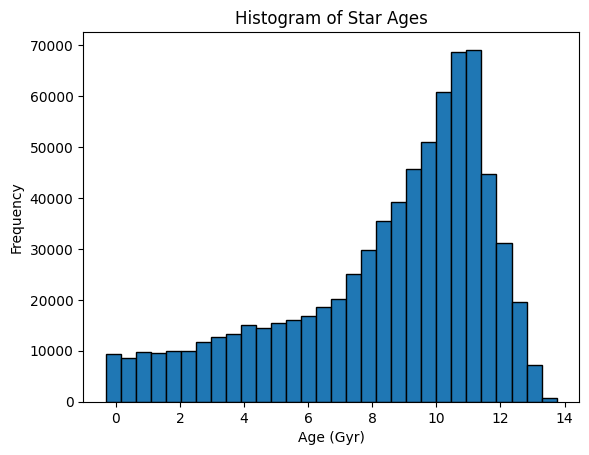

In [26]:
# NBVAL_SKIP
import matplotlib.pyplot as plt

# Plot a histogram of the velocities
plt.hist(inputdata.stars.age[:], bins=30, edgecolor='black')
plt.xlabel('Age (Gyr)')
plt.ylabel('Frequency')
plt.title('Histogram of Star Ages')
plt.savefig(f"./output/hub2026/nihao826e11_gcs_no_noise_no_psf/age_{galaxy_id}_{component}.jpeg")
plt.show()

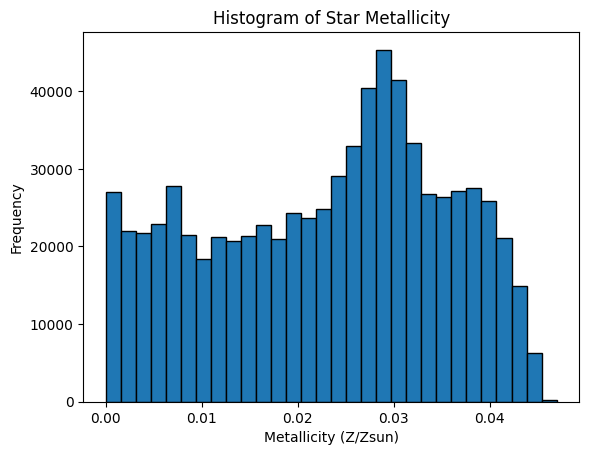

In [27]:
# NBVAL_SKIP
import matplotlib.pyplot as plt

# Plot a histogram of the velocities
plt.hist(inputdata.stars.metallicity[:], bins=30, edgecolor='black')
plt.xlabel('Metallicity (Z/Zsun)')
plt.ylabel('Frequency')
plt.title('Histogram of Star Metallicity')
plt.savefig(f"./output/hub2026/nihao826e11_gcs_no_noise_no_psf/metallicity_{galaxy_id}_{component}.jpeg")
plt.show()